In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')

In [ ]:
print(df.duplicated().sum())

0


In [8]:
chol = (df['Cholesterol'] == 0).sum()
print("Number of zero values in cholestrol column :",chol)
bp = (df['RestingBP'] == 0).sum()
print("Number of zero values in RestingBP column :",bp)

Number of zero values in cholestrol column : 172
Number of zero values in RestingBP column : 1


In [15]:
print("Before Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())
chol = df[df['Cholesterol'] != 0]
chol_mean = chol['Cholesterol'].mean()
print("Mean of Cholesterol (excluding zeros):", chol_mean)

bp = df[df['RestingBP'] != 0]
bp_mean = bp['RestingBP'].mean()
print("Mean of RestingBP (excluding zeros):", bp_mean)

# Replace 0 values with mean
df['Cholesterol'] = df['Cholesterol'].replace(0, chol_mean)
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)
print()
print("After Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
Mean of Cholesterol (excluding zeros): 244.63625272331154
Mean of RestingBP (excluding zeros): 132.54089324618738

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


In [18]:
chol = (df['Cholesterol'] == 0).sum()
print("Number of zero values in cholestrol column :",chol)
bp = (df['RestingBP'] == 0).sum()
print("Number of zero values in RestingBP column :",bp)

Number of zero values in cholestrol column : 0
Number of zero values in RestingBP column : 0


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

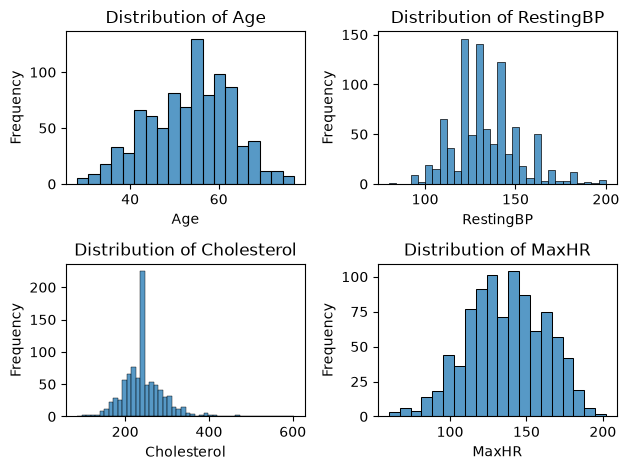

In [21]:
def checkCanvas(col, pos):
    plt.subplot(2, 2, pos)
    sns.histplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Function calls
checkCanvas("Age", 1)
checkCanvas("RestingBP", 2)
checkCanvas("Cholesterol", 3)
checkCanvas("MaxHR", 4)

plt.tight_layout()
plt.show()

In [23]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:",num_cols)
print("Categorical Columns:",cat_cols)

Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')
Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


C:\Users\batul\AppData\Local\Temp\ipykernel_6992\2162913166.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [25]:
df["RestingBP"].unique()

array([140.  , 160.  , 130.  , 138.  , 150.  , 120.  , 110.  , 136.  ,
       115.  , 100.  , 124.  , 113.  , 125.  , 145.  , 112.  , 132.  ,
       118.  , 170.  , 142.  , 190.  , 135.  , 180.  , 108.  , 155.  ,
       128.  , 106.  ,  92.  , 200.  , 122.  ,  98.  , 105.  , 133.  ,
        95.  ,  80.  , 137.  , 185.  , 165.  , 126.  , 152.  , 116.  ,
       132.54, 144.  , 154.  , 134.  , 104.  , 139.  , 131.  , 141.  ,
       178.  , 146.  , 158.  , 123.  , 102.  ,  96.  , 143.  , 172.  ,
       156.  , 114.  , 127.  , 101.  , 174.  ,  94.  , 148.  , 117.  ,
       192.  , 129.  , 164.  ])

In [26]:
df_encoded = pd.get_dummies(df['Sex'])
print(df_encoded)
print("Shape :",df_encoded.shape)
df_encoded.head()

         F      M
0    False   True
1     True  False
2    False   True
3     True  False
4    False   True
..     ...    ...
913  False   True
914  False   True
915  False   True
916   True  False
917  False   True

[918 rows x 2 columns]
Shape : (918, 2)


,F,M
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True


In [33]:
cat_cols = df.select_dtypes(include=['object']).columns

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols)

# Print shape
print("Shape of encoded dataframe:", df_encoded.shape)

# Print first 5 rows
print("First 5 rows:")
print(df_encoded.head())

Shape of encoded dataframe: (918, 21)
First 5 rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LV

C:\Users\batul\AppData\Local\Temp\ipykernel_6992\3457860468.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
print("Shape after encoding :",df_encoded.shape)
print("List of columns :",df_encoded.columns)


Shape after encoding : (918, 21)
List of columns : Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')
Shape of encoded dataframe: (918, 21)
First 5 rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType

C:\Users\batul\AppData\Local\Temp\ipykernel_6992\1541578225.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [38]:
cat_cols = df.select_dtypes(include=['object']).columns

# encode first
df_encoded = pd.get_dummies(df, columns=cat_cols)

# then split
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

print(X.head())
print(y.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0   40      140.0        289.0          0    172      0.0  False   True   
1   49      160.0        180.0          0    156      1.0   True  False   
2   37      130.0        283.0          0     98      0.0  False   True   
3   48      138.0        214.0          0    108      1.5   True  False   
4   54      150.0        195.0          0    122      0.0  False   True   

   ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0              False               True              False             False   
1              False              False               True             False   
2              False               True              False             False   
3               True              False              False             False   
4              False              False               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseAngina_

C:\Users\batul\AppData\Local\Temp\ipykernel_6992\3046392472.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
X = df.drop("HeartDisease", axis=1)         # From here
y = df["HeartDisease"]

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

# Perform One-Hot Encoding on X only
X = pd.get_dummies(X, columns=cat_cols)

# Output
print(X.head())
print(y.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0   40      140.0        289.0          0    172      0.0  False   True   
1   49      160.0        180.0          0    156      1.0   True  False   
2   37      130.0        283.0          0     98      0.0  False   True   
3   48      138.0        214.0          0    108      1.5   True  False   
4   54      150.0        195.0          0    122      0.0  False   True   

   ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0              False               True              False             False   
1              False              False               True             False   
2              False               True              False             False   
3               True              False              False             False   
4              False              False               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseAngina_

C:\Users\batul\AppData\Local\Temp\ipykernel_6992\775851465.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


In [40]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (734, 20)
X_test shape: (184, 20)
y_train shape: (734,)
y_test shape: (184,)


In [43]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression()

# Train (fit) the model
model.fit(X_train, y_train)

c:\Users\batul\OneDrive\Desktop\ITR_Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [44]:
y_pred = model.predict(X_test)

# Print first 10 actual vs predicted values
print("Actual values (y_test):")
print(y_test.head(10).values)

print("\nPredicted values (y_pred):")
print(y_pred[:10])

Actual values (y_test):
[0 1 1 1 0 1 1 0 1 1]

Predicted values (y_pred):
[0 0 1 1 0 1 1 0 1 1]


In [45]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display matrix
print("Confusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nLabeled Output:")
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

Confusion Matrix:
 [[68  9]
 [16 91]]

Labeled Output:
True Negative (TN): 68
False Positive (FP): 9
False Negative (FN): 16
True Positive (TP): 91


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8641304347826086
Precision: 0.91
Recall: 0.8504672897196262
F1 Score: 0.8792270531400966

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



In [48]:
import joblib

# Save the trained model
joblib.dump(model, "heart_model.pkl")
# Save column names (important for future predictions)
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']

In [49]:
import joblib

# Load model and columns
model = joblib.load("heart_model.pkl")
columns = joblib.load("columns.pkl")

print("Model and columns loaded!")

Model and columns loaded!


In [51]:
import pandas as pd

sample_data = pd.DataFrame([{
    "Age": 45,
    "Sex": "M",
    "ChestPainType": "ATA",
    "RestingBP": 120,
    "Cholesterol": 240,
    "FastingBS": 0,
    "RestingECG": "Normal",
    "MaxHR": 150,
    "ExerciseAngina": "N",
    "Oldpeak": 1.0,
    "ST_Slope": "Up"
}])
# Apply same encoding
sample_encoded = pd.get_dummies(sample_data)
# Add missing columns
sample_encoded = sample_encoded.reindex(columns=columns, fill_value=0)
prediction = model.predict(sample_encoded)

print("Prediction:", prediction[0])
if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Prediction: 0
No Heart Disease


In [52]:
df["FastingBS"].unique()

array([0, 1])